In [2]:
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [15]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


# My Notes on Normalization: Viewing It as an Affine Transformation


When studiyng machine learning and deep learning, I was confused by the different normalizations found in several courses and literature. 
In this notebook, I would like to share my comprehension of it. 

The different kinds of normalizations are  special cases of  the one-dimensional affine transformation

$$  X^\prime =  b \,X - a$$

If $X$ denotes the dataset, then  this transformation  works as follows:

* Scaling data by a factor of $b$

* Translating $X$ to the left  by $a$ units. 
 


The factor $b$ stretches or shrinks the data range. If $0< b < 1$, it shrinks the range,  and if $ b> 1$, it stretches the data range. 

Let us see a simple example of what this transformation does on some data.

As a simple example, let us take $a = 3$ and $b=1/2$. So, the transformation  is $$X^\prime = \frac{1}{2}X - 3\,,$$ 




In [3]:
# generating randomness
np.random.seed(82)

# Original data
X = np.random.randint(2, 15, size=20) 

print(f" Orinigal X: {X}")
print("========================================================")

# Transformed data
Xp = X / 2 - 3
print(f" Transformed X_prime: {Xp}")

len(X)

 Orinigal X: [ 5  4  5 13  8  4  2 12  3 14  3 13  5  5 11  7  6  2  3 11]
 Transformed X_prime: [-0.5 -1.  -0.5  3.5  1.  -1.  -2.   3.  -1.5  4.  -1.5  3.5 -0.5 -0.5
  2.5  0.5  0.  -2.  -1.5  2.5]


20

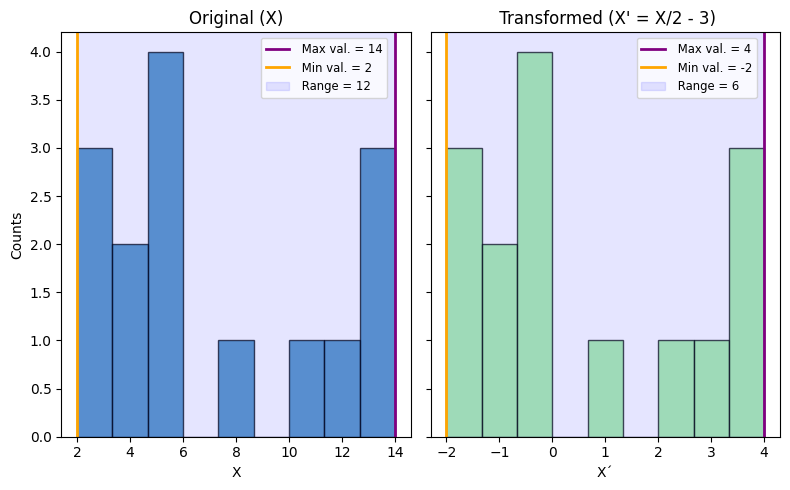

In [4]:
#========================
# Plot Histograms - Range
#========================

# Data configuration
np.random.seed(82)
X = np.random.randint(2, 15, size=15)
X_prime = X / 2 - 3

# Range
range_X = X.max() - X.min() 
range_Xp = Xp.max() - Xp.min() 

# Number of bins (same for both)
num_bins = 10

# Bins aligned with each dataset
bins_X = np.linspace(X.min(), X.max(), num_bins)
bins_Xp = np.linspace(X_prime.min(), X_prime.max(), num_bins)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# Original histogram 
ax1.hist(X, bins = bins_X, color='tab:blue', edgecolor='black', alpha=0.7)
ax1.set_title(f'Original (X)')

# Reference lines
ax1.axvline(X.max(), color="purple",  linewidth=2, label= f" Max val. = {X.max():.0f}")
ax1.axvline(X.min(), color="orange",  linewidth=2, label= f" Min val. = {X.min():.0f}")
ax1.axvspan(X.min(), X.max(), alpha = 0.1, color = "blue",
           label = f" Range = {range_X:.0f}")

ax1.legend(loc='upper right',  bbox_to_anchor=(0.95, 1), fontsize='small')
ax1.set_ylabel("Counts")
ax1.set_xlabel("X")


# Transformed histogram 
# bins are 1/2  width 
ax2.hist(X_prime, bins = bins_Xp, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_title(f" Transformed (X' = X/2 - 3)")
# Líneas de referencia
ax2.axvline(Xp.max(), color="purple",  linewidth=2, label= f" Max val. = {Xp.max():.0f}")
ax2.axvline(Xp.min(), color="orange",  linewidth=2, label= f" Min val. = {Xp.min():.0f}")
ax2.axvspan(Xp.min(), Xp.max(), alpha = 0.1, color = "blue",
           label = f" Range = {range_Xp:.0f}")
ax2.legend(loc='upper right',  bbox_to_anchor=(0.95, 1),fontsize='small')
ax2.set_xlabel("X´")


plt.tight_layout()
plt.show()


The range of the dataset was reduced to a half, while the shape of the distribution is preserved. 

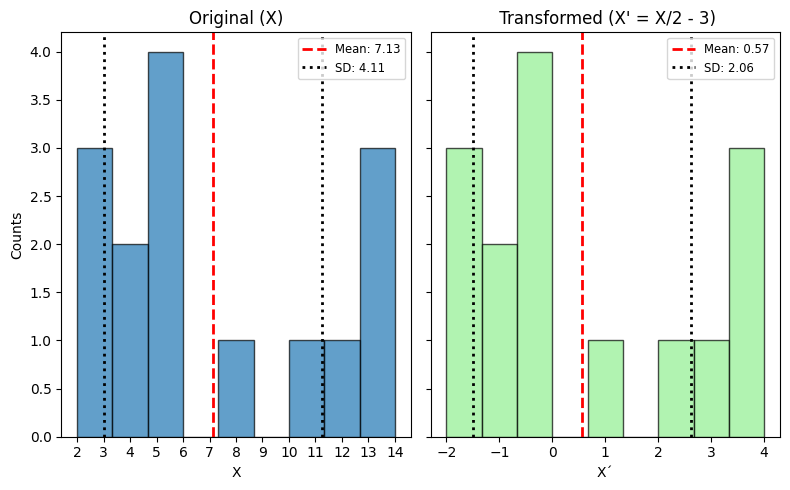

In [19]:
#===========================
# Plot Histograms - Mean-SD
#===========================


# Data configuration
np.random.seed(82)
X = np.random.randint(2, 15, size=15)
X_prime = X / 2 - 3


# Statistical quantities
mean = np.mean(X)
pmean = np.mean(X_prime)

sd = np.std(X)
psd = np.std(X_prime)

# Number of bins (same for both)
num_bins = 10

# Bins aligned with each dataset
bins_X = np.linspace(X.min(), X.max(), num_bins)
bins_Xp = np.linspace(X_prime.min(), X_prime.max(), num_bins)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# Original histogram 
ax1.hist(X, bins= bins_X, color='tab:blue', edgecolor='black', alpha=0.7)
ax1.set_title(f'Original (X)')
ax1.set_xticks(range(2, 15))

# Reference lines
ax1.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean:.2f}")
ax1.axvline(mean - sd, color="black", linestyle=":", linewidth=2, label=f"SD: {sd:.2f}")
ax1.axvline(mean + sd, color="black", linestyle=":", linewidth=2)
ax1.legend(loc='upper right', fontsize='small')
ax1.set_ylabel("Counts")
ax1.set_xlabel("X")

# Transformed histogram 
# bins are 1/2  width 
ax2.hist(X_prime, bins=bins_Xp, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_title(f" Transformed (X' = X/2 - 3)")
# Líneas de referencia
ax2.axvline(pmean, color="red", linestyle="--", linewidth=2, label=f"Mean: {pmean:.2f}")
ax2.axvline(pmean - psd, color="black", linestyle=":", linewidth=2, label=f"SD: {psd:.2f}")
ax2.axvline(pmean + psd, color="black", linestyle=":", linewidth=2)
ax2.legend(loc='upper right', fontsize='small')
ax2.set_xlabel("X´")

plt.tight_layout()
plt.show()


In this case, the mean was reduced by half and then translated 3 units to the left. The standard deviation was reduced by half. 
So in general, 

if      $X´= b\,X-a$
                
then the mean $\mu$  and  the standard deviation $\sigma$ are transformed as  
$\mu´ = b\,\mu -a$

$\sigma´ = |b| \,\sigma$.

From these results, we observe that the transformation considered does not change the form of the data distribution. It just scales it and changes its location. 

#  Special cases  of the 1D affine transformation

## Min-Max Normalization

This transformation has the form
$$
X^\prime = \frac{(X-X_{min})}{X_{max} - X_{min}}
$$
This is an affine transformation with  $b = 1 / \mbox{range}\,(X)$ and  $a = X_{min}/ \mbox{range}\,(X)$ where $\mbox{range}(X) = X_{max} - X_{min}$. 
* For the case $X_{min} = 0$, there is not translations and the transformation is only a scaling: $$X^\prime = \frac{X}{X_{max}} \,.$$  Then if the data takes values in the interval $[0, X_{max}]$, after this transformation the data take values in $[0, 1]$.



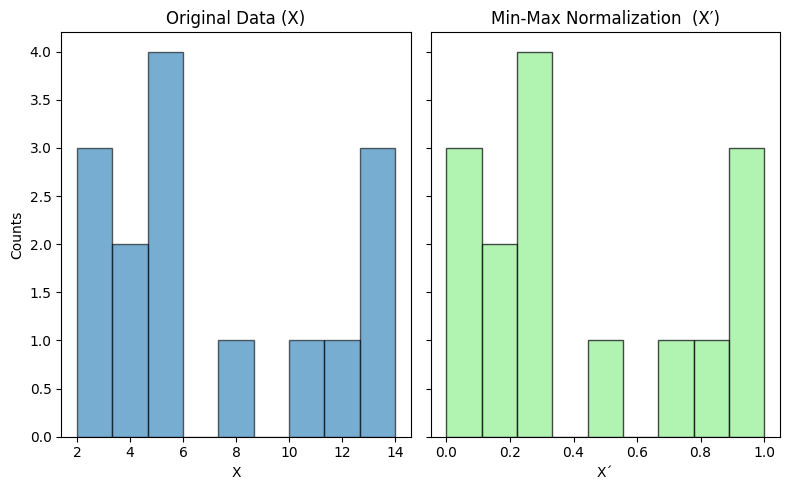

In [5]:
#========================
# Min-Max Normalization
#========================

Xmax = X.max()
Xmin = X.min()

X_minmax = (X - Xmin) / (Xmax - Xmin)


# Number of bins (same for both)
num_bins = 10

# Bins aligned with each dataset
bins_X = np.linspace(X.min(), X.max(), num_bins)
bins_X_minmax = np.linspace(X_minmax.min(), X_minmax.max(), num_bins)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# ---- Original Data ----
ax1.hist(X, bins= bins_X, alpha=0.6,  edgecolor='black')
ax1.set_title("Original Data (X)")
ax1.set_xlabel("X")
ax1.set_ylabel("Counts")

# ---- Min-Max normalized Data ----
ax2.hist(X_minmax, bins=bins_X_minmax, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_title("Min-Max Normalization  (X′)")
ax2.set_xlabel("X´")


plt.tight_layout()
plt.show()

##  (Z-score) normalization or Standardization

The  standardization is obtained when the statistical measures mean $\mu$ and standard deviation $\sigma$ are used in the transformation: 
$$
X^\prime = \frac{(X-\mu)}{\sigma}
$$

It is an affine transformation of the form $X´ = b\, X - a$ with $b = 1/\sigma$, and     $a = \mu / \sigma$. 
This transformation makes the dataset $X^\prime$  with mean  0 and standard deviation 1.

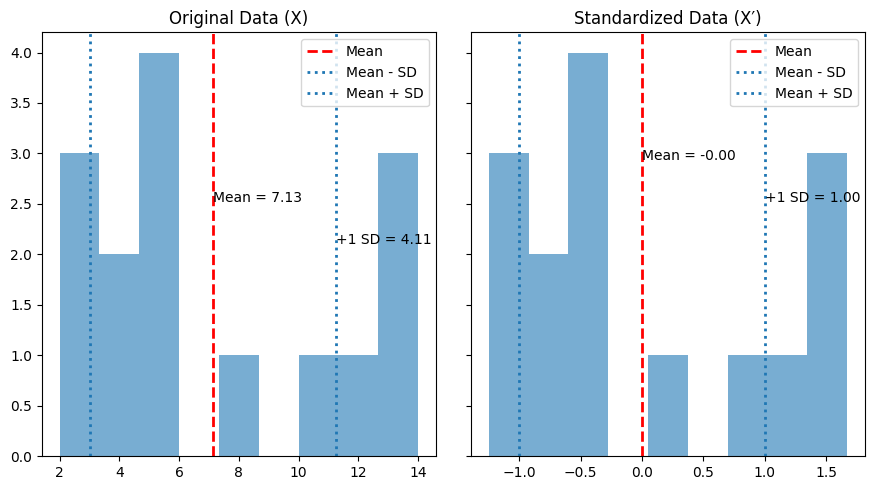

In [16]:
#=========================
# Standardization
#=========================

# Transformed X by standardization
X_prime = (X - mean) / sd

mean = np.mean(X)
sd = np.std(X)

pmean = np.mean(X_prime)
psd = np.std(X_prime)


# Number of bins (same for both)
num_bins = 10

# Bins aligned with each dataset
bins_X = np.linspace(X.min(), X.max(), num_bins)
bins_Xprime = np.linspace(X_prime.min(), X_prime.max(), num_bins)



#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(9,5), sharey=True)

# ---- Original Data ----
axes[0].hist(X, bins=bins_X, alpha=0.6)
axes[0].axvline(mean, linestyle="--", linewidth=2, label="Mean", color = "red")
axes[0].axvline(mean - sd, linestyle=":", linewidth=2, label="Mean - SD")
axes[0].axvline(mean + sd, linestyle=":", linewidth=2, label="Mean + SD")
axes[0].text(mean, axes[0].get_ylim()[1]*0.6, 
             f"Mean = {mean:.2f}", rotation=0)
axes[0].text(mean + sd, 
            axes[0].get_ylim()[1]*0.5, 
            f"+1 SD = {sd:.2f}",
           horizontalalignment='left')
axes[0].set_title("Original Data (X)")
axes[0].legend()

# ---- Standardized Data ----
axes[1].hist(X_prime, bins=bins_Xprime,  alpha=0.6)
axes[1].axvline(pmean, linestyle="--", linewidth=2, label="Mean", color = "red")
axes[1].axvline(pmean - psd, linestyle=":", linewidth=2, label="Mean - SD")
axes[1].axvline(pmean + psd, linestyle=":", linewidth=2, label="Mean + SD")
axes[1].text(pmean, axes[1].get_ylim()[1]*0.7, 
             f"Mean = {pmean:.2f}", rotation=0)
axes[1].text(pmean + psd, 
             axes[1].get_ylim()[1]*0.6, 
             f"+1 SD = {psd:.2f}",
             horizontalalignment='left')

axes[1].set_title("Standardized Data (X′)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
print("Min of Transformed X:", round(X_prime.min(),2))
print("Max of Transformed X:", round(X_prime.max(),2))

Min of Transformed X: -1.25
Max of Transformed X: 1.67


This normalization reduced the interval [2, 14] to [-1,3, 1.7] with mean 0 and standard deviation 1. 